## Project1/Milestone 3: Used Car Price Prediction 
Class: "DSC680-T301 Applied Data Science (2267-1)<br>
Student: "Roshan GC" <br>
Professor: "Xu Ashton" <br>
Date: "07/05/2026"

## Description
This notebook contains the Python code used for data analysis and used car price prediction.

## Import required libraries and load dataset

In [27]:
# importing required libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Load dataset
df = pd.read_csv("/users/roshan/DSC680/CAR_DETAILS_FROM_CAR_DEKHO.csv")

# Preview data
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [29]:
# print data details
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [ ]:
# Create vehicle age column
df["car_age"] = 2026 - df["year"]

# preview data after adding car_age column
print("Rows and Columns:", df.shape)
df.head()

Rows and Columns: (4340, 9)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12


## Visualization

# Figure 1. Distribution of Selling Prices 

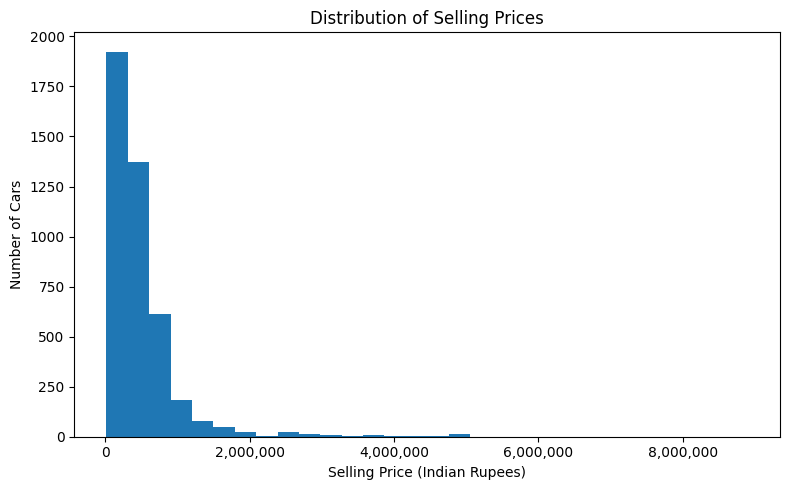

In [31]:
# Chart 1: Distribution of Selling Price
plt.figure(figsize=(8, 5))
plt.hist(df["selling_price"], bins=30)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price (Indian Rupees)")
plt.ylabel("Number of Cars")

# Showing full price values
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

## Figure 2. Selling Price by Vehicle Year 

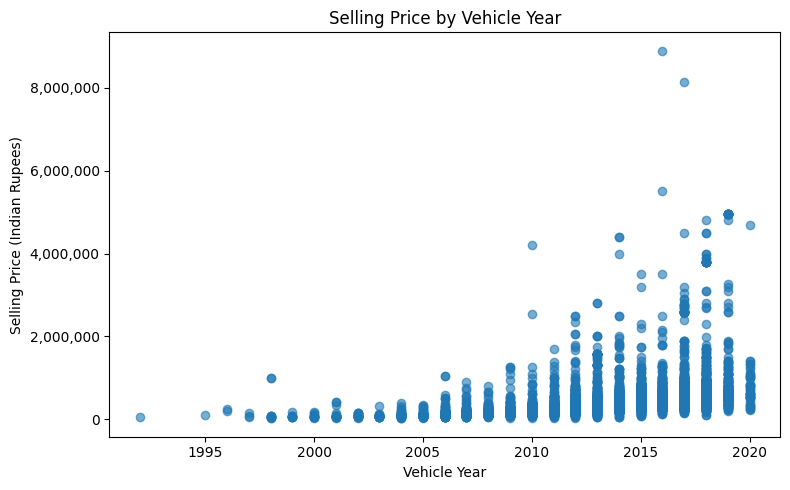

In [32]:
# Chart 2: Selling Price by Vehicle Year
plt.figure(figsize=(8, 5))
plt.scatter(df["year"], df["selling_price"], alpha=0.6)

plt.title("Selling Price by Vehicle Year")
plt.xlabel("Vehicle Year")
plt.ylabel("Selling Price (Indian Rupees)")

# Show full price values
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

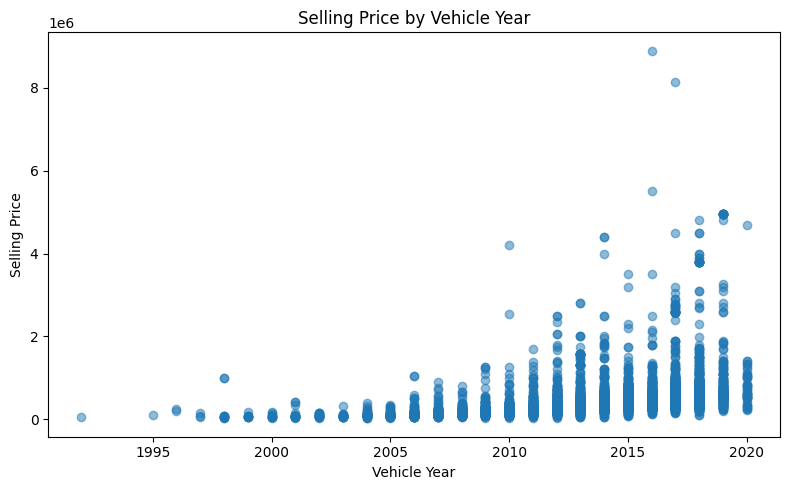

In [6]:
# Chart 2: Selling price by year
plt.figure(figsize=(8, 5))
plt.scatter(df["year"], df["selling_price"], alpha=0.5)
plt.title("Selling Price by Vehicle Year")
plt.xlabel("Vehicle Year")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.savefig("figure2_price_by_year.png")
plt.show()

## Figure 3. Selling Price vs. Kilometers Driven

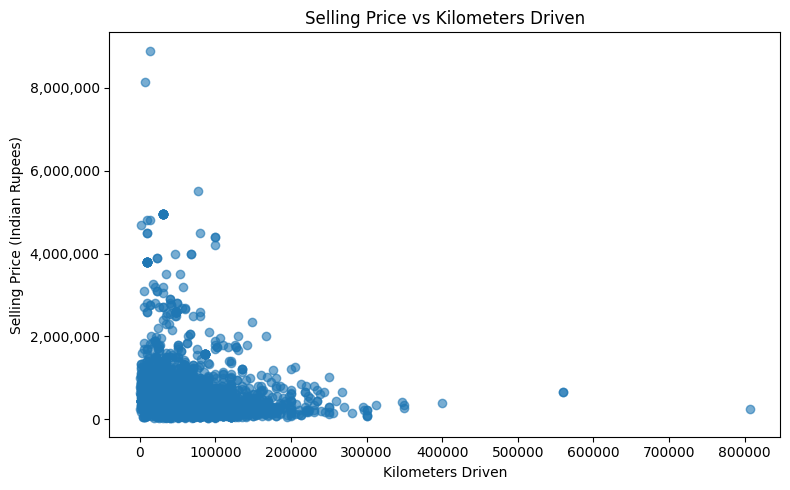

In [33]:
# Chart 3: Selling Price vs Kilometers Driven
plt.figure(figsize=(8, 5))
plt.scatter(df["km_driven"], df["selling_price"], alpha=0.6)

plt.title("Selling Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (Indian Rupees)")

# Display full price values
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

## Figure 4. Distribution of Fuel Types 

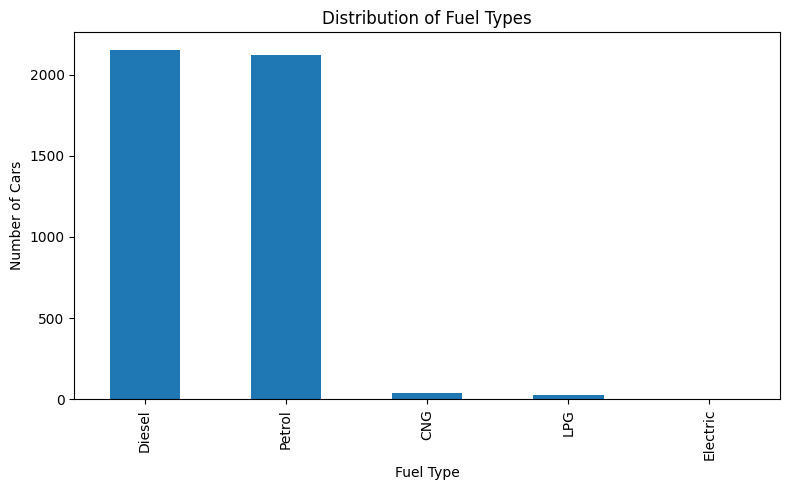

In [8]:
# Chart 4: Fuel type distribution
fuel_counts = df["fuel"].value_counts()

plt.figure(figsize=(8, 5))
fuel_counts.plot(kind="bar")
plt.title("Distribution of Fuel Types")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.savefig("figure4_fuel_type_distribution.png")
plt.show()

## Figure 5. Distribution of Transmission Types

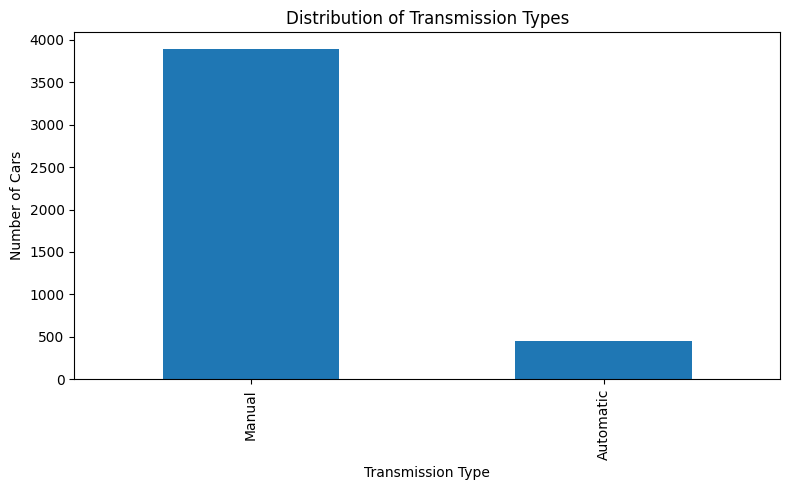

In [34]:
# Chart 5: Transmission distribution
transmission_counts = df["transmission"].value_counts()

plt.figure(figsize=(8, 5))
transmission_counts.plot(kind="bar")
plt.title("Distribution of Transmission Types")
plt.xlabel("Transmission Type")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.savefig("figure5_transmission_distribution.png")
plt.show()

## Data Preprocessing and Train-Test Split

In [10]:
# Prepare data for modeling
X = df[["year", "km_driven", "fuel", "seller_type", "transmission", "owner"]]
y = df["selling_price"]

categorical_features = ["fuel", "seller_type", "transmission", "owner"]
numeric_features = ["year", "km_driven"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Linear Regression Model

In [11]:
# Linear Regression model
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R-squared:", r2_score(y_test, linear_pred))

Linear Regression Results
MAE: 221706.36930921228
RMSE: 426786.6899872169
R-squared: 0.40313036014333026


## Random Forest Regression Model

In [12]:
# Random Forest Regression model
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_estimators=100))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Regression Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R-squared:", r2_score(y_test, rf_pred))

Random Forest Regression Results
MAE: 168075.10208773977
RMSE: 390833.8603969908
R-squared: 0.4994561613692253


Note: 
Please refer to the accompanying white paper for detailed explanations of the project methodology, analysis, and findings.